# Quickstart

**pyplotrs in fifteen minutes.** By the end of this notebook you will have made
a figure, styled it, read it back, and saved it as an editable-text PDF — which
is most of what the library is.

Everything here runs on a plain `pip install pyplotrs`. There are no runtime
dependencies: no NumPy, no matplotlib, nothing to configure.

```bash
pip install pyplotrs
```

**Where to go after this**

| Notebook | For |
|---|---|
| [Coming from matplotlib](02_from_matplotlib.ipynb) | The API differences, side by side with matplotlib renders |
| [Plot types](03_plot_types.ipynb) | Every mark in the vocabulary |
| [Layout and composition](04_layout_and_composition.ipynb) | Grids, spanning panels, twin and secondary axes, insets, colorbars |
| [Styling and color](05_styling_and_color.ipynb) | Themes, palettes, the 127 colormaps, norms, color science |
| [Text and math](06_text_and_math.ipynb) | Fonts, styling one word of a label, and `$…$` with no LaTeX |
| [Animation](07_animation.ipynb) | A figure per frame, GIF and APNG |
| [Output formats and performance](08_output_and_performance.ipynb) | PDF/SVG/PNG/HTML, threads, and the speed against matplotlib |

In [1]:
import math
import tempfile
from pathlib import Path

import pyplotrs as pp

# Somewhere disposable for the files this notebook saves.
OUT = Path(tempfile.mkdtemp(prefix="pyplotrs-quickstart-"))

print("pyplotrs", pp.__version__, "· body font:", pp.resolved_font_name())

pyplotrs 0.1.0 · body font: Arial


## 1 · The whole loop

Make a figure, draw on the axes, save it. That is the entire API shape.

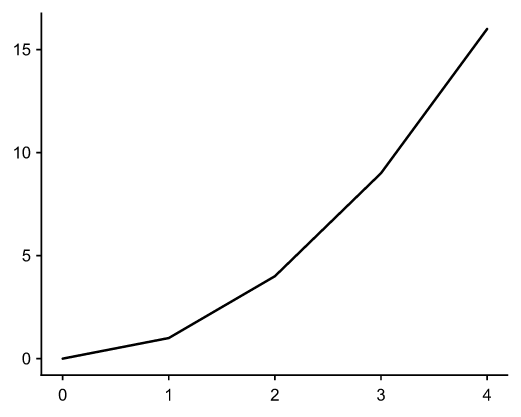

In [2]:
fig, ax = pp.subplots()
ax.line([0, 1, 2, 3, 4], [0, 1, 4, 9, 16])
fig

That figure is 250 × 200 **points** — a single journal column — with a
colorblind-safe palette, despined axes and nice-number ticks. Publication size
and publication styling are the defaults, not something you switch on.

In a notebook, a bare `fig` at the end of a cell displays it: `Figure` implements
`_repr_png_`. There is no `show()` to call, and no interactive window.

### There is no current figure

`fig` and `ax` are ordinary objects. Nothing is registered in a global registry,
so a function that builds a figure can simply return it, and two figures built in
the same script — or in two threads — never interfere.

<Figure 220x150pt, 1x1 grid, 1 axes, 1 mark>
<Figure 220x150pt, 1x1 grid, 1 axes, 1 mark>


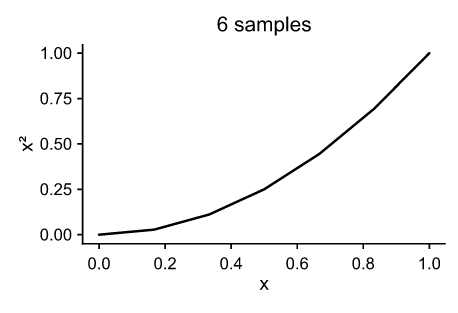

In [3]:
def parabola(n: int, *, color: str):
    """A figure is a value, so a function can return one."""
    xs = [i / n for i in range(n + 1)]
    fig, ax = pp.subplots(figsize=(220, 150))
    ax.line(xs, [x * x for x in xs], color=color)
    ax.set(title=f"{n} samples", xlabel="x", ylabel="x²")
    return fig


coarse = parabola(6, color="C0")
smooth = parabola(200, color="C3")
print(repr(coarse))
print(repr(smooth))
coarse

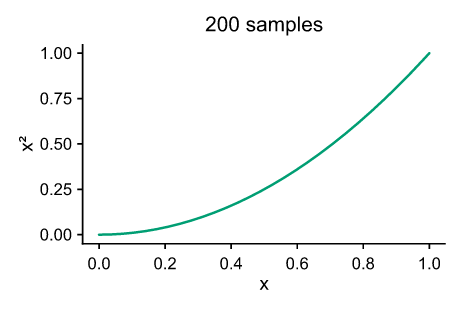

In [4]:
smooth

## 2 · Marks

An `Axes` carries a vocabulary of *marks* — `line`, `scatter`, `bar`, `hist`,
`errorbar`, `imshow` and about thirty more. Each returns the axes, so calls
chain, and each takes the next color from the theme's palette unless you name
one.

`label=` on a mark plus `legend()` is the whole legend story: the keys are built
from the marks themselves, so a legend can never disagree with its plot.

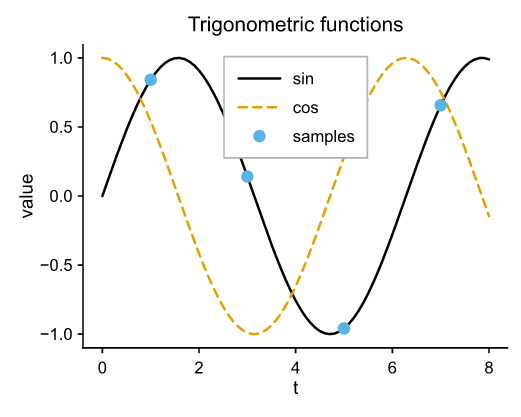

In [5]:
xs = [i * 0.1 for i in range(81)]

fig, ax = pp.subplots()
ax.line(xs, [math.sin(x) for x in xs], label="sin")
ax.line(xs, [math.cos(x) for x in xs], label="cos", linestyle="dashed")
ax.scatter([1, 3, 5, 7], [math.sin(v) for v in (1, 3, 5, 7)], label="samples")
ax.legend()
ax.set(title="Trigonometric functions", xlabel="t", ylabel="value")
fig

## 3 · `set()` writes, `get_*()` reads

There is no `set_xlabel` / `set_xlim` / `set_xscale` family. One method takes
every axes property as a keyword:

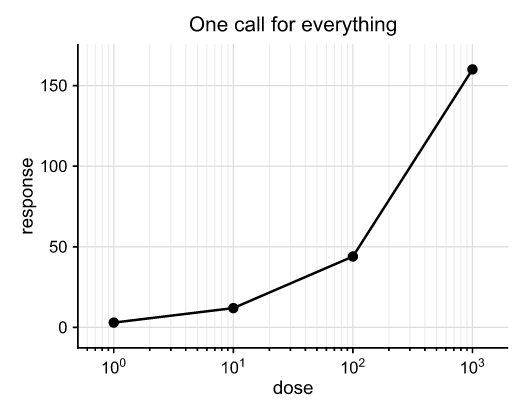

In [6]:
fig, ax = pp.subplots()
ax.line([1, 10, 100, 1000], [3, 12, 44, 160], marker="o")
ax.set(title="One call for everything",
       xlabel="dose", ylabel="response",
       xscale="log", grid=True, margin=0.1)
fig

Reading goes back through the `get_*` accessors, and every one of them reports
the **effective** value — what will actually be drawn, autoscaling and tick
location included — not just whatever you happened to set.

In [7]:
fig, ax = pp.subplots()
ax.line(xs, [math.sin(x) for x in xs])

print("xlim        ", ax.get_xlim())        # autoscaled: nothing was set
print("xticks      ", ax.get_xticks())      # where the locator put them
print("yticklabels ", ax.get_yticklabels())  # the strings that will be drawn
print("yscale      ", ax.get_yscale())

xlim         (-0.4, 8.4)
xticks       [0.0, 2.0, 4.0, 6.0, 8.0]
yticklabels  ['−1.0', '−0.5', '0.0', '0.5', '1.0']
yscale       linear


Note the minus signs in those labels: they are U+2212 MINUS SIGN, not the
hyphen-minus you typed. That is a typographic default, and
`pp.set_unicode_minus(False)` turns it off.

## 4 · Saving

The file extension chooses the format. Nothing else changes.

In [8]:
fig, ax = pp.subplots()
ax.line(xs, [math.exp(-0.3 * x) * math.cos(3 * x) for x in xs], label="response")
ax.legend()
ax.set(title="Damped oscillation", xlabel="t (s)", ylabel="amplitude")

for name in ("figure.pdf", "figure.svg", "figure.png", "figure.html"):
    fig.save(str(OUT / name))
    print(f"{name:<12} {(OUT / name).stat().st_size / 1024:7.1f} KB")

fig.save(str(OUT / "hires.png"), dpi=600)          # raster resolution
fig.save(str(OUT / "clear.png"), transparent=True)  # no background fill

figure.pdf      15.8 KB
figure.svg     363.4 KB
figure.png      21.7 KB
figure.html    363.8 KB


Two of those formats are worth a closer look, because they are the reason the
library exists.

**The PDF and SVG keep text as text.** Fonts are embedded and subset, never
converted to outlines, so every label stays selectable, extractable and
re-typeable in Illustrator or Inkscape. You can see it without leaving the
notebook — the SVG contains `<text>` elements, and the characters are still
characters:

In [9]:
import re

svg = (OUT / "figure.svg").read_text()
texts = re.findall(r"<text[^>]*>([^<]*)</text>", svg)
print(f"{len(texts)} <text> elements, not outlines:")
print(" ", texts)

13 <text> elements, not outlines:
  ['0', '2', '4', '6', '8', '−0.5', '0.0', '0.5', '1.0', 'Damped oscillation', 't (s)', 'amplitude', 'response']


**The HTML is self-contained.** One file, with the font and any math inlined —
open it on a machine with no network and it renders identically, because it
fetches nothing:

In [10]:
html = (OUT / "figure.html").read_text()
remote = re.findall(r"<(?:script|link|img)[^>]*(?:src|href)=\"https?://[^\"]*\"", html)
print(f"{len(html) / 1024:.0f} KB, {len(remote)} remote resources fetched on open")

364 KB, 0 remote resources fetched on open


## 5 · Panels

Pass a grid shape to `subplots`. A single row or column gives a flat list of
axes; a full grid gives a list of rows, so `axs[1][0]` is row 1, column 0.

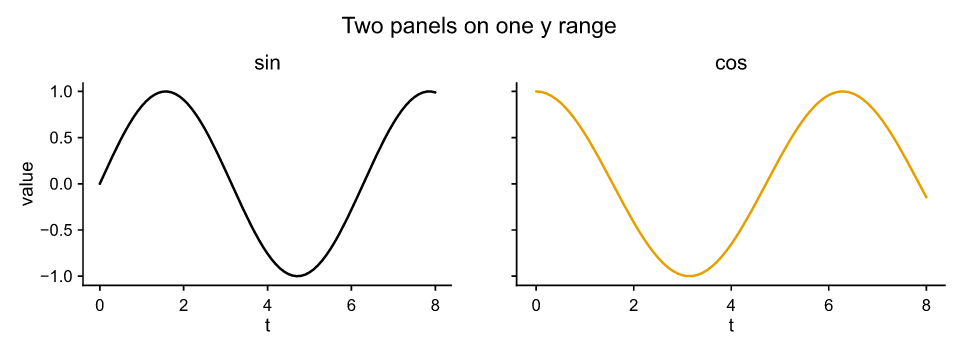

In [11]:
fig, axs = pp.subplots(1, 2, figsize=(460, 170), sharey=True)
axs[0].line(xs, [math.sin(x) for x in xs], color="C0")
axs[1].line(xs, [math.cos(x) for x in xs], color="C1")
axs[0].set(title="sin", xlabel="t", ylabel="value")
# `sharey` unifies the range; the labels are still yours, so drop the ones that
# would just repeat the panel on their left.
axs[1].set(title="cos", xlabel="t", yticklabels=[])
fig.set(suptitle="Two panels on one y range")
fig

`sharey=True` gives both panels one y range, computed over both sets of data, so
the two curves are comparable by eye. It does *not* touch the tick labels — that
stays an explicit `yticklabels=[]`, because "the panel on the left already says
this" is a judgment about the layout rather than about the data.

There is no `tight_layout()` to call afterwards: layout is solved before anything
is drawn, so labels and titles have already been measured and given room.

Uneven grids, spanning panels, insets and twin axes are all in the
[layout notebook](04_layout_and_composition.ipynb).

## 6 · Size is in points

`figsize` is `(width, height)` in **points** (1 pt = 1/72 in) rather than
inches, so a figure's size can be reasoned about directly against its font size:
a 250 pt canvas with 9 pt tick labels is a ratio you can picture. Pass `units=`
for anything else.

canvas: (252, 170) pt


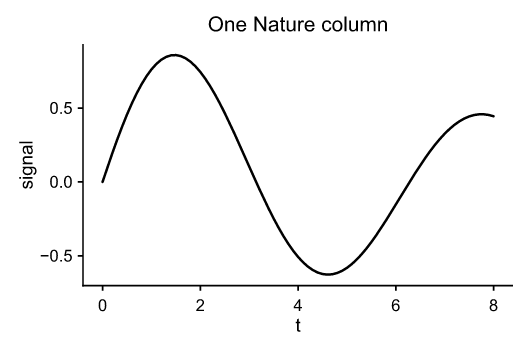

In [12]:
# A single Nature column is 89 mm. Ask for that, not for 3.504 inches.
fig, ax = pp.subplots(figsize=(89, 60), units="mm")
ax.line(xs, [math.sin(x) * math.exp(-0.1 * x) for x in xs])
ax.set(title="One Nature column", xlabel="t", ylabel="signal")
print("canvas:", tuple(round(v) for v in fig.size_pt), "pt")
fig

Because the canvas is the real, final size, the type on it is the real, final
type: an 11 pt title in this notebook is an 11 pt title in the manuscript. There
is no scaling step between here and the page.

## 7 · What you can hand it

Marks take **any iterable of numbers** — lists, tuples, generators, `array`,
NumPy arrays, pandas or polars columns. NumPy is used when it is there (there is
a fast path for contiguous arrays) and never required.

Two input types also pick the axis *type* for you, and non-finite values are
handled rather than plotted:

category ticks: ['ash', 'birch', 'cedar', 'elm']
date ticks:     ['2023', '2024', '2025', '2026']


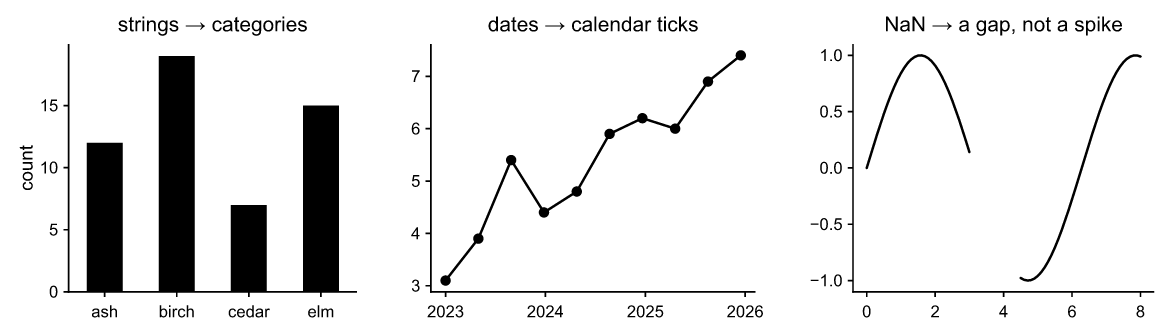

In [13]:
from datetime import date, timedelta

fig, axs = pp.subplots(1, 3, figsize=(560, 160))

# Strings on an axis mean a categorical scale, with one tick per category.
axs[0].bar(["ash", "birch", "cedar", "elm"], [12, 19, 7, 15])
axs[0].set(title="strings → categories", ylabel="count")

# dates/datetimes mean a date scale, with ticks chosen in calendar units -
# years, months or days as the span requires, never "1.7688e9".
start = date(2023, 1, 1)
days = [start + timedelta(days=120 * i) for i in range(10)]
axs[1].line(days, [3.1, 3.9, 5.4, 4.4, 4.8, 5.9, 6.2, 6.0, 6.9, 7.4], marker="o")
axs[1].set(title="dates → calendar ticks")

# NaN breaks the line into a gap and is ignored when autoscaling, rather than
# being plotted as zero or dragging the limits to infinity.
gappy = [math.sin(x) if not (3.0 < x < 4.5) else float("nan") for x in xs]
axs[2].line(xs, gappy)
axs[2].set(title="NaN → a gap, not a spike")

print("category ticks:", axs[0].get_xticklabels())
print("date ticks:    ", axs[1].get_xticklabels())
fig

## 8 · Themes are an argument

Styling is not global state. There is no `rcParams` and no `style.use()`: a
theme is an immutable object you pass to `subplots`, so two figures in one
script — or in two threads — can look completely different without either
leaking into the other.

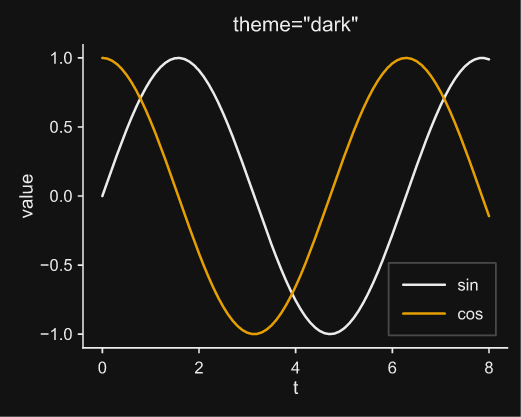

In [14]:
fig, ax = pp.subplots(theme="dark")
ax.line(xs, [math.sin(x) for x in xs], label="sin")
ax.line(xs, [math.cos(x) for x in xs], label="cos")
ax.legend()
ax.set(title="theme=\"dark\"", xlabel="t", ylabel="value")
fig

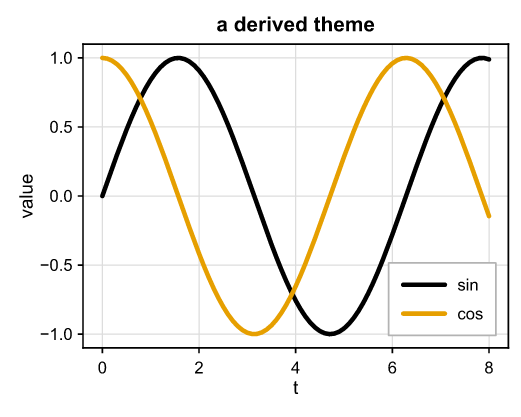

In [15]:
# Derive your own with `with_`, which returns a new theme and mutates nothing.
mine = pp.themes.default.with_(grid=True, line_width=2.2, title_weight="bold",
                               spines=("left", "bottom", "top", "right"))

fig, ax = pp.subplots(theme=mine)
ax.line(xs, [math.sin(x) for x in xs], label="sin")
ax.line(xs, [math.cos(x) for x in xs], label="cos")
ax.legend()
ax.set(title="a derived theme", xlabel="t", ylabel="value")
fig

## What you now know

- `subplots` → marks → `fig.save(...)`, with no global state in between.
- `set(**kwargs)` writes an axes and `get_*()` reads back the effective value.
- The extension picks the format, and PDF/SVG keep text as real text.
- Sizes are in points, so the figure is already at publication size.
- Themes and figures are values you pass around.

**Next:** if you are arriving from matplotlib, the
[differences](02_from_matplotlib.ipynb) are the fastest thing to read next —
it renders the same data in both libraries so you can see what changes. If you
just want to know what can be drawn, go to [plot types](03_plot_types.ipynb).